# Collector Location Clustering

Notebook ini memilih **K-Means** sebagai metode clustering untuk mengelompokkan sebaran lokasi penyetor menjadi tiga wilayah layanan. Centroid bukan metode tambahan, melainkan output alami dari K-Means yang digunakan sebagai rekomendasi awal titik collector strategis.

**Alasan memilih K-Means:** data memiliki banyak titik koordinat tanpa label cluster. K-Means dapat membagi seluruh penyetor secara otomatis berdasarkan kedekatan lokasi sekaligus menghasilkan titik pusat untuk setiap kelompok.

Output utama:

- Cluster 1
- Cluster 2
- Cluster 3
- koordinat rekomendasi collector pada setiap cluster, dan
- scatter plot sebaran penyetor beserta centroid.

In [1]:
from pathlib import Path
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

plt.style.use("ggplot")
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

## 1. Memuat data lokasi penyetor

Setiap penyetor memiliki koordinat `latitude` dan `longitude`. Kolom `average_volume` disimpan untuk merangkum potensi volume per cluster, tetapi pembentukan cluster hanya menggunakan lokasi agar rekomendasi collector berfokus pada kedekatan geografis.

In [2]:
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
data_path = project_root / "data" / "depositor_locations_dummy.csv"

df = pd.read_csv(data_path)
df.head()

,depositor_id,depositor_name,latitude,longitude,average_volume
0,DEP001,Penyetor 001,-6.174500,106.822700,145
1,DEP002,Penyetor 002,-6.181200,106.829400,210
2,DEP003,Penyetor 003,-6.168800,106.835100,175
3,DEP004,Penyetor 004,-6.190500,106.817800,240
4,DEP005,Penyetor 005,-6.156900,106.824500,130


In [3]:
required_columns = [
    "depositor_id",
    "depositor_name",
    "latitude",
    "longitude",
    "average_volume",
]

missing_columns = [column for column in required_columns if column not in df.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

if df[required_columns].isna().any().any():
    raise ValueError("The dataset contains missing values.")

if not df["latitude"].between(-90, 90).all():
    raise ValueError("Latitude values must be between -90 and 90.")

if not df["longitude"].between(-180, 180).all():
    raise ValueError("Longitude values must be between -180 and 180.")

print(f"Number of depositors: {len(df)}")
print(f"Missing values: {df[required_columns].isna().sum().sum()}")

Number of depositors: 45
Missing values: 0


## 2. Metode terpilih: K-Means

K-Means dipilih sebagai satu-satunya metode clustering. Jumlah cluster ditetapkan menjadi tiga sesuai kebutuhan tiga area collector. `random_state` digunakan agar hasil dapat direproduksi.

In [4]:
coordinate_columns = ["latitude", "longitude"]
coordinates = df[coordinate_columns]

number_of_clusters = 3
kmeans = KMeans(n_clusters=number_of_clusters, random_state=42, n_init=10)
raw_labels = kmeans.fit_predict(coordinates)
raw_centroids = kmeans.cluster_centers_

# Sort centroids from west to east to produce stable business-friendly labels.
sorted_raw_labels = np.argsort(raw_centroids[:, 1])
label_mapping = {
    int(raw_label): f"Cluster {position + 1}"
    for position, raw_label in enumerate(sorted_raw_labels)
}

df["cluster"] = [label_mapping[int(label)] for label in raw_labels]

centroid_rows = []
for raw_label, centroid in enumerate(raw_centroids):
    centroid_rows.append({
        "cluster": label_mapping[raw_label],
        "collector_latitude": centroid[0],
        "collector_longitude": centroid[1],
    })

centroids_df = pd.DataFrame(centroid_rows).sort_values("cluster").reset_index(drop=True)
centroids_df

c:\Users\LENOVO\miniconda3\envs\mlenv\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,cluster,collector_latitude,collector_longitude
0,Cluster 1,-6.177227,106.824533
1,Cluster 2,-6.277373,106.832487
2,Cluster 3,-6.225947,106.889780


Centroid merupakan hasil yang dihitung oleh model K-Means, bukan metode clustering terpisah. Dalam studi awal, titik ini digunakan sebagai kandidat lokasi collector karena K-Means mencari pusat yang meminimalkan jumlah kuadrat jarak seluruh penyetor terhadap pusat clusternya. Lokasi akhir tetap perlu mempertimbangkan akses jalan, biaya lahan, kapasitas, dan batas administratif.

## 3. Output rekomendasi collector

Setiap cluster menghasilkan output dengan struktur berikut:

- `recommended_location`: rekomendasi koordinat collector,
- `radius_km`: persentil ke-90 jarak penyetor dari titik rekomendasi, dan
- `potential_volume`: total potensi volume penyetor dalam cluster.

In [5]:
def haversine_distance(latitude_1, longitude_1, latitude_2, longitude_2):
    earth_radius_km = 6371.0088

    latitude_1_rad = np.radians(latitude_1)
    latitude_2_rad = np.radians(latitude_2)
    latitude_difference = np.radians(latitude_2 - latitude_1)
    longitude_difference = np.radians(longitude_2 - longitude_1)

    haversine_value = (
        np.sin(latitude_difference / 2) ** 2
        + np.cos(latitude_1_rad)
        * np.cos(latitude_2_rad)
        * np.sin(longitude_difference / 2) ** 2
    )
    angular_distance = 2 * np.arctan2(
        np.sqrt(haversine_value), np.sqrt(1 - haversine_value)
    )

    return earth_radius_km * angular_distance


df = df.merge(centroids_df, on="cluster", how="left")
df["distance_to_centroid_km"] = df.apply(
    lambda row: haversine_distance(
        row["latitude"],
        row["longitude"],
        row["collector_latitude"],
        row["collector_longitude"],
    ),
    axis=1,
)

cluster_summary = (
    df.groupby("cluster", as_index=False)
    .agg(
        depositor_count=("depositor_id", "count"),
        potential_volume=("average_volume", "sum"),
        average_depositor_volume=("average_volume", "mean"),
        radius_km=(
            "distance_to_centroid_km",
            lambda distances: np.percentile(distances, 90),
        ),
    )
    .merge(centroids_df, on="cluster", how="left")
    .sort_values("cluster")
    .reset_index(drop=True)
)

cluster_summary["cluster_id"] = (
    cluster_summary["cluster"].str.extract(r"(\d+)")[0].astype(int)
)

cluster_summary

,cluster,depositor_count,total_average_volume,average_depositor_volume,collector_latitude,collector_longitude
0,Cluster 1,15,2810,187.333333,-6.177227,106.824533
1,Cluster 2,15,3175,211.666667,-6.277373,106.832487
2,Cluster 3,15,3215,214.333333,-6.225947,106.889780


In [6]:
cluster_outputs = []

for _, row in cluster_summary.iterrows():
    cluster_outputs.append({
        "recommended_location": {
            "latitude": round(float(row["collector_latitude"]), 6),
            "longitude": round(float(row["collector_longitude"]), 6),
        },
        "radius_km": round(float(row["radius_km"]), 2),
        "potential_volume": int(row["potential_volume"]),
    })

print(json.dumps(cluster_outputs, indent=2))

silhouette = silhouette_score(coordinates, raw_labels)
print(f"Silhouette score: {silhouette:.4f}")

Cluster 1: 15 depositors
Cluster 2: 15 depositors
Cluster 3: 15 depositors
Silhouette score: 0.6068


**Interpretasi:** `radius_km` menggunakan persentil ke-90, sehingga sekitar 90% anggota cluster berada di dalam radius layanan. Pendekatan ini lebih tahan terhadap beberapa penyetor yang lokasinya sangat jauh dibandingkan menggunakan jarak maksimum. Jumlah anggota dan total volume membantu melihat beban potensial setiap collector. Silhouette score digunakan sebagai pemeriksaan kualitas pemisahan cluster.

## 4. Visualisasi scatter plot

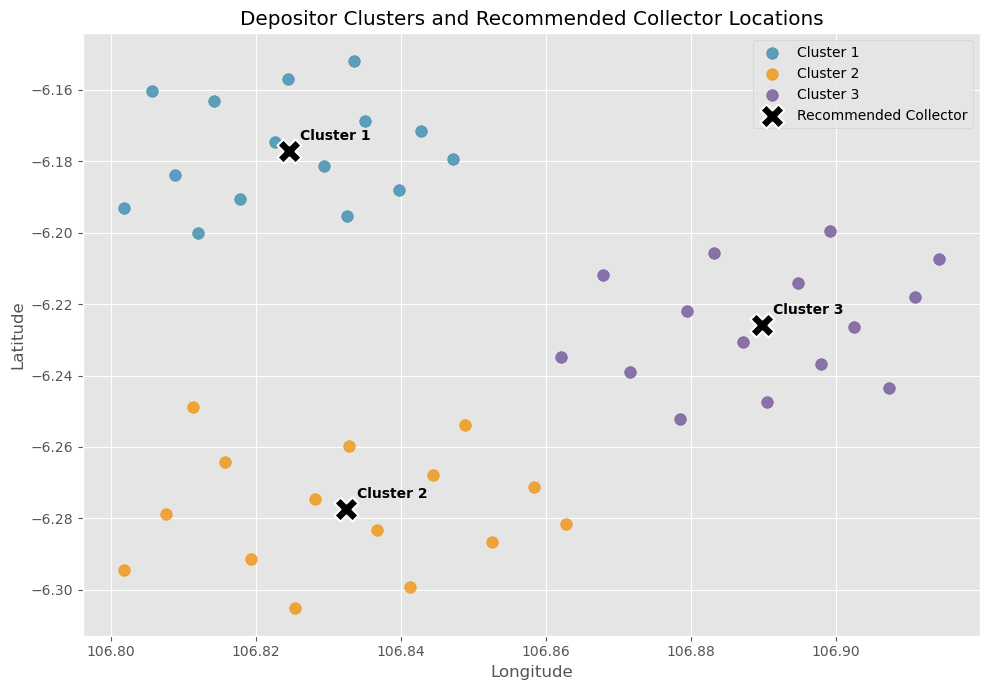

In [7]:
cluster_colors = {
    "Cluster 1": "#2E86AB",
    "Cluster 2": "#F18F01",
    "Cluster 3": "#6A4C93",
}

fig, ax = plt.subplots(figsize=(10, 7))

for cluster_name, cluster_data in df.groupby("cluster"):
    ax.scatter(
        cluster_data["longitude"],
        cluster_data["latitude"],
        s=70,
        alpha=0.75,
        color=cluster_colors[cluster_name],
        label=cluster_name,
    )

ax.scatter(
    centroids_df["collector_longitude"],
    centroids_df["collector_latitude"],
    marker="X",
    s=300,
    color="black",
    edgecolor="white",
    linewidth=1.5,
    label="Recommended Collector",
)

for _, row in centroids_df.iterrows():
    ax.annotate(
        row["cluster"],
        (row["collector_longitude"], row["collector_latitude"]),
        xytext=(8, 8),
        textcoords="offset points",
        fontweight="bold",
    )

ax.set(
    title="Depositor Clusters and Recommended Collector Locations",
    xlabel="Longitude",
    ylabel="Latitude",
)
ax.legend()
plt.tight_layout()
plt.show()

**Interpretasi:** Setiap warna menunjukkan wilayah layanan collector yang berbeda. Simbol X hitam menunjukkan centroid dan menjadi rekomendasi awal titik collector. Penyetor dapat diarahkan ke collector yang berada pada cluster yang sama.

## 5. Rekomendasi collector terdekat

Fungsi berikut menerima koordinat penyetor dan membandingkan jaraknya dengan ketiga centroid menggunakan rumus Haversine. Hasilnya adalah cluster dan titik collector terdekat.

In [8]:
def recommend_collector(latitude, longitude, collector_locations):
    recommendations = collector_locations.copy()
    recommendations["distance_km"] = recommendations.apply(
        lambda row: haversine_distance(
            latitude,
            longitude,
            row["collector_latitude"],
            row["collector_longitude"],
        ),
        axis=1,
    )

    nearest = recommendations.sort_values("distance_km").iloc[0]
    return {
        "recommended_cluster": nearest["cluster"],
        "collector_latitude": round(float(nearest["collector_latitude"]), 6),
        "collector_longitude": round(float(nearest["collector_longitude"]), 6),
        "distance_km": round(float(nearest["distance_km"]), 2),
    }


sample_recommendation = recommend_collector(
    latitude=-6.2200,
    longitude=106.8900,
    collector_locations=centroids_df,
)
sample_recommendation

{'recommended_cluster': 'Cluster 3',
 'collector_latitude': -6.225947,
 'collector_longitude': 106.88978,
 'distance_km': 0.66}

## 6. Menyimpan model dan hasil cluster

In [9]:
models_directory = project_root / "models"
models_directory.mkdir(parents=True, exist_ok=True)

model_package = {
    "model": kmeans,
    "coordinate_columns": coordinate_columns,
    "label_mapping": label_mapping,
    "collector_locations": centroids_df,
}

model_path = models_directory / "collector_clustering_model.joblib"
joblib.dump(model_package, model_path)

cluster_output_path = project_root / "data" / "depositor_cluster_results.csv"
df.to_csv(cluster_output_path, index=False)

print(f"Model saved to: {model_path}")
print(f"Cluster results saved to: {cluster_output_path}")

Model saved to: c:\Projects\Play IT\hen-waste-oil-ml\models\collector_clustering_model.joblib
Cluster results saved to: c:\Projects\Play IT\hen-waste-oil-ml\data\depositor_cluster_results.csv


## 7. Kesimpulan

- Metode yang dipilih adalah K-Means.
- K-Means berhasil membagi penyetor menjadi Cluster 1, Cluster 2, dan Cluster 3.
- Centroid yang dihasilkan K-Means menjadi rekomendasi awal lokasi collector untuk wilayah clusternya.
- Output setiap rekomendasi berisi `recommended_location`, `radius_km`, dan `potential_volume`.
- `radius_km` menggunakan persentil ke-90 agar rekomendasi tidak terlalu dipengaruhi oleh outlier lokasi.
- Scatter plot memperlihatkan sebaran penyetor, pembagian cluster, dan posisi collector.
- Fungsi rekomendasi dapat menentukan collector terdekat untuk koordinat penyetor baru.
- Centroid adalah rekomendasi berbasis koordinat. Penentuan lokasi operasional akhir tetap memerlukan validasi lapangan dan pertimbangan akses jalan.